# Cosmos Reason 2 — Edge Compilation on Thor AGX / DGX Spark (NVFP4)

In [notebook 05](05_cosmos_reason_end_to_end.ipynb) we took NVIDIA's [`nvidia/Cosmos-Reason2-2B`](https://huggingface.co/nvidia/Cosmos-Reason2-2B) reasoning VLM and ran the full **prune → distill → FP8** pipeline *on a training server*. That produced a pruned-and-distilled student that recovers the baseline's reasoning quality at ~15 % fewer LM parameters, plus FP8 checkpoints for both the original and the distilled model.

This notebook is the **second half of the story: getting that server-trained model to run fast on the edge.** We are now on an **NVIDIA Thor AGX or a DGX Spark**. They are `aarch64` Blackwell-class devices with unified memory architectures. Physical-AI deployments (robots, AVs, embodied agents) run *here*, not in the datacenter, and the constraints flip: smaller footprint, a power budget, and a hard real-time latency target.

One of Blackwell's headline inference features is the **FP4 tensor core**. So the edge-specific lever we add on top of the server pipeline is **NVFP4** — NVIDIA's 4-bit floating-point format (E2M1 elements + per-16-block FP8 scales). The goal of this notebook:

1. **Stand up a Thor/Spark-native toolchain**.
2. **Quantize to NVFP4**.
3. **Compile + serve** on Thor/Spark with vLLM (`torch.compile` + CUDA-graph capture on Blackwell).
4. **Benchmark four deployable variants**, original FP8, distilled FP8, original NVFP4, distilled NVFP4, on both **quality** (RealWorldQA, Blink), **speed** (aiperf: TTFT / E2E latency), and **energy per decision**.

| Stage | What it does | Wall-time (approx.) |
|---|---|---|
| §1 Toolchain | `aarch64` container: vLLM base + modelopt + eval tooling | one-time image build |
| §2 Artifacts | Pull the four server-built checkpoints onto the device | — |
| §3 NVFP4 theory | Format, Blackwell FP4 cores, **which layers to keep in higher precision** — plus visuals | read |
| §4 Quantize | NVFP4 PTQ (image-aware calib) for original + distilled | ~1 min each |
| §5 Compile + serve | vLLM `torch.compile` + CUDA graphs → OpenAI endpoint | ~1 min spin-up |
| §6 Quality | 4-way BLINK / RealWorldQA + a qualitative showdown | 20–40 min, live progress |
| §7 Speed | aiperf robotics suite: energy / latency / TTFT | 15–30 min, live progress |

---
## 1. An aarch64 Thor/Spark-native toolchain

Notebook 05 ran inside `nvcr.io/nvidia/nemo:26.04`. That image is **x86-only for our purposes**: it *does* publish an `arm64` manifest, but that build targets **SBSA / datacenter ARM** (GH200-class), **not Tegra/Thor/Spark**. The main issue is that `sm_110/sm_121` kernels will be missing.

Here the pipeline is only **quantize → compile → serve → benchmark**, which needs **modelopt + vLLM + eval tooling**.

The base image we use is an **L4T/Thor vLLM engineering image** that ships the pre-built stack and GPU-verified on the device: `torch 2.13`, `vLLM 0.22.1`, FlashAttention, FlashInfer, xformers, Triton, CUDA 13.x, `transformers 5.6`. On top of it we layer only thin, pure-Python additions (modelopt from source, `datasets`, `accelerate`, `lmms-eval`, `aiperf`). The full recipe is captured in [`Dockerfile.thor`](Dockerfile.thor) and the matching [`.devcontainer/thor`](../../../.devcontainer/thor/devcontainer.json). Make sure to build the image following README_thor_spark.MD and start this jupyter notebook from inside the container.

> 🧩 **Tegra detail.** On Thor the GPU is exposed through the **NVIDIA container runtime**, not the `--gpus` flag. Launch with `--runtime nvidia --ipc=host` (see the devcontainer `runArgs`). `nvidia-smi` reports unified memory as `N/A` for total, that's normal; memory is shared with the CPU.

> 🟢 **Running on a DGX Spark (GB10) instead?** This *same* image works unchanged, its `TORCH_CUDA_ARCH_LIST=…12.0+PTX` JIT-compiles forward to GB10's `sm_121`, and the prebuilt FlashAttention / FlashInfer kernels run (verified). Two deltas only: **(1)** launch with **`--gpus all`** instead of `--runtime nvidia` (the container toolkit is present but no named `nvidia` runtime is registered), and **(2)** §7 reads power via **NVML** instead of the INA3221 sysfs rails. Both are handled below. See [`README_thor_spark.md`](README_thor_spark.md).

In [1]:
# Where everything lives on the device. The devcontainer bind-mounts the host's
# model directory to /hf, exactly like notebook 05.
import os
BASE_PATH = "/hf"

# Confirm we are on Thor and the prebuilt stack is intact.
import torch, transformers, vllm, modelopt
print(f"arch                : {os.uname().machine}")
print(f"device              : {torch.cuda.get_device_name(0)}")
print(f"compute capability  : {torch.cuda.get_device_capability(0)}")
print(f"torch               : {torch.__version__}")
print(f"transformers        : {transformers.__version__}")
print(f"vllm                : {vllm.__version__}")
print(f"modelopt            : {modelopt.__version__}")

from huggingface_hub import get_token
print(f"HF token            : {'present' if get_token() else 'MISSING — §6 quality evals will fail (README step 4)'}")

arch                : aarch64
device              : NVIDIA GB10
compute capability  : (12, 1)
torch               : 2.13.0a0+8145d630e8.nvinternal.main
transformers        : 5.6.0
vllm                : 0.22.1+97be4ec1.dev
modelopt            : 0.45.0.dev106+g8112ae9ae.d20260610


---
## 2. The artifacts from the server

Four checkpoints come over from notebook 05. The two BF16 models (original and distilled Cosmos-Reason2) and the respective FP8 pair. Now we will generate two NVFP4 checkpoints for Thor/Spark.

| Variant | Path | Precision | Role |
|---|---|---|---|
| baseline (ref) | `Cosmos-Reason2-2B` | BF16 | original, unpruned |
| distilled (ref) | `Cosmos-Reason2-distilled` | BF16 | pruned + distilled |
| **orig_fp8** | `Cosmos-Reason2-fp8` | FP8 | original quantized FP8 |
| **distilled_fp8** | `Cosmos-Reason2-distilled-fp8` | FP8 | pruned + distilled + quantized FP8 |
| **orig_nvfp4** | `Cosmos-Reason2-nvfp4` | NVFP4 | **built in §4** |
| **distilled_nvfp4** | `Cosmos-Reason2-distilled-nvfp4` | NVFP4 | **built in §4** |

In [2]:
import os, json
VARIANTS = {
    "orig_fp8":        f"{BASE_PATH}/Cosmos-Reason2-fp8",
    "distilled_fp8":   f"{BASE_PATH}/Cosmos-Reason2-distilled-fp8",
    "orig_nvfp4":      f"{BASE_PATH}/Cosmos-Reason2-nvfp4",
    "distilled_nvfp4": f"{BASE_PATH}/Cosmos-Reason2-distilled-nvfp4",
}
for name in ["Cosmos-Reason2-2B", "Cosmos-Reason2-distilled"]:
    p = f"{BASE_PATH}/{name}/model.safetensors"
    if os.path.exists(p):
        print(f"{name:<32} {os.path.getsize(p)/1e9:5.2f} GB  BF16 (reference)")

Cosmos-Reason2-2B                 4.88 GB  BF16 (reference)
Cosmos-Reason2-distilled          3.85 GB  BF16 (reference)


---
## 3. NVFP4 on Blackwell

**NVFP4** packs each weight as a 4-bit float (1 sign / 2 exponent / 1 mantissa = E2M1) and attaches a small **FP8 (E4M3) scale per block of 16 elements**, with a per-tensor global scale on top. Two-level scaling is what lets 4-bit hold accuracy: the block scale tracks local dynamic range, the global scale tracks the tensor. On **Blackwell** the FP4 tensor cores execute these natively, so NVFP4 GEMMs run at roughly **2× the math throughput of FP8** and move half the activation bytes, which is exactly the lever you want on a bandwidth-bound edge part like Thor.

![FP8 E4M3 vs NVFP4 E2M1 — bit anatomy, every representable magnitude, and NVFP4's two-level scaling](https://developer-blogs.nvidia.com/wp-content/uploads/2025/06/nvfp4-two-level-scaling.gif)

### Best practice: do **not** quantize sensitive layers

4-bit is aggressive. Quantizing *everything* to NVFP4 reliably hurts quality, and a few layers carry far more of that damage than the rest. The production NVFP4 recipes encode which ones to spare:

```yaml
ignore:
  - 're:.*lm_head'        # output projection — tiny, but high-precision-sensitive
  - 're:visual.*'         # the entire vision encoder
```

The principle, which generalises across LLMs and VLMs:

| Keep in higher precision | Why |
|---|---|
| **Vision encoder + projector** | VLM vision towers are very sensitive to compression; they are also a small share of params. Quantizing them buys little and costs a lot. |
| **`lm_head`** | The final logit projection; quantization error here lands directly on the token distribution. |
| **Embeddings / LayerNorms** | Not GEMM-bound; no throughput upside, and comes with a high accuracy risk. |
| **MoE router/gate** | A wrong routing decision is unrecoverable downstream (not applicable to dense Cosmos-Reason2). |

**ModelOpt applies this for you on a VLM.** When `hf_ptq.py` sees a VLM and you pass `--calib_with_images`, it restricts quantization to the **language tower** and writes the exclusion set into `hf_quant_config.json`. You'll see `exclude_modules: ["lm_head", "model.visual*"]` in §4, i.e. the suggested recipe, applied automatically. The vision encoder, projector, embeddings and `lm_head` all stay BF16; only the Qwen3 decoder's attention + MLP linears go to NVFP4.

> 📐 **What we tested (and why we stopped at the default).** For a small dense decoder like this one, the next question is whether to *also* spare sensitive *decoder* layers (e.g. keep the first/last transformer block in FP8). We measured the default recipe (all LM-tower linears in NVFP4, vision + `lm_head` excluded) against the FP8 baselines on the judge-free benchmarks in §6. NVFP4's cost vs FP8 on the original model is just **0–7 points**, at or below the ±5–7 % noise floor of a 100-sample slice, while NVFP4 delivers ~1.17× decode throughput and lower latency (§7). Carving out extra "sensitive" decoder layers to FP8 would chase a few points of noise while eroding the speed win, so we **stay with the default**. For experimentation, other strategies can be explored with auto_quantize or custom search algorithms.

#### Seeing the formats

The figure is **generated live from your checkpoint**, one real attention weight quantized both ways, so you see exactly what §4 is about to do to this model. Its important to note that this is only half the story, we are not considering activation range in this simplified visualization example.

layer: model.language_model.layers.0.self_attn.q_proj.weight   shape: (2048, 2048)
relative RMSE   FP8: 2.648%   NVFP4: 9.457%


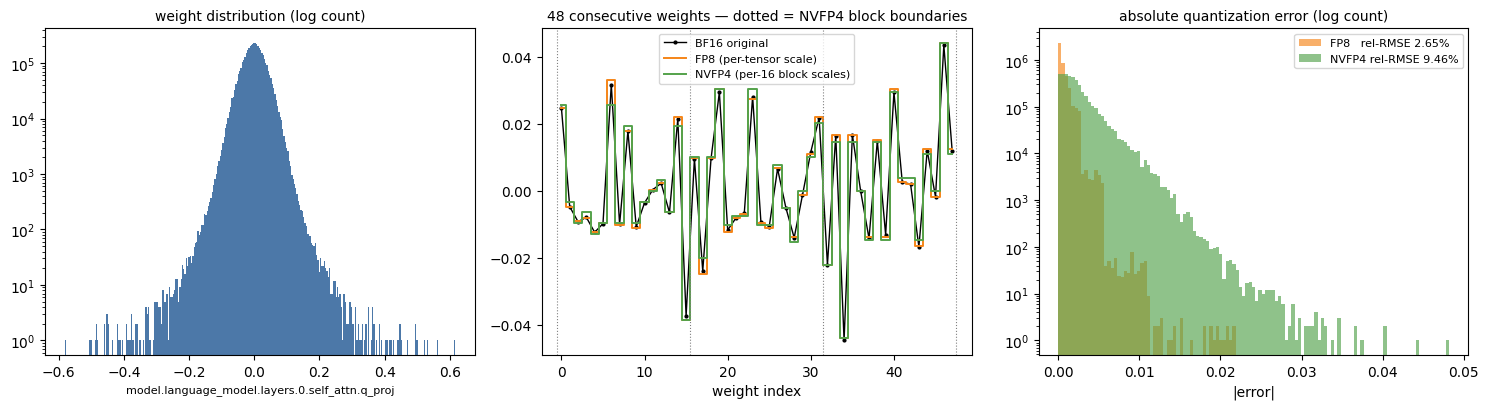

In [12]:
# §3 visual — take one REAL decoder weight from this checkpoint and quantize it.
# FP8: one per-tensor scale (modelopt's FP8 default, axis=None). NVFP4: per-16
# E4M3 block scales + FP32 per-tensor scale = amax/(6*448) (nvfp4_tensor.py).
# Round-to-nearest simulation — faithful enough to teach with, not a kernel.
import torch
import matplotlib.pyplot as plt
from safetensors import safe_open

assert "BASE_PATH" in globals(), "Run the §1 environment cell first (defines BASE_PATH)."
with safe_open(f"{BASE_PATH}/Cosmos-Reason2-2B/model.safetensors", framework="pt") as f:
    keys = sorted(k for k in f.keys() if "q_proj.weight" in k and "visual" not in k)
    key = next((k for k in keys if ".layers.0." in k), keys[0])
    W = f.get_tensor(key).float()
print(f"layer: {key}   shape: {tuple(W.shape)}")

def to_e4m3(x):                                   # round through real FP8 encoding
    return x.clamp(-448, 448).to(torch.float8_e4m3fn).float()

def quant_fp8_per_tensor(w):
    s = w.abs().max() / 448.0
    return to_e4m3(w / s) * s

E2M1 = torch.tensor([0.0, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0, 6.0])
BOUND = (E2M1[1:] + E2M1[:-1]) / 2                # round-to-nearest decision points

def quant_nvfp4(w):
    blk = w.reshape(-1, 16)
    s_tensor = w.abs().max() / (6.0 * 448.0)              # FP32 per-tensor scale
    s_block = to_e4m3(blk.abs().amax(1) / 6.0 / s_tensor)  # E4M3 per-block scales
    scale = (s_block * s_tensor).clamp_min(1e-12).unsqueeze(1)
    q = E2M1[torch.bucketize((blk / scale).abs(), BOUND)] * blk.sign()
    return (q * scale).reshape(w.shape)

w8, w4 = quant_fp8_per_tensor(W), quant_nvfp4(W)
rel_rmse = lambda a: float((a - W).pow(2).mean().sqrt() / W.pow(2).mean().sqrt())
print(f"relative RMSE   FP8: {rel_rmse(w8):.3%}   NVFP4: {rel_rmse(w4):.3%}")

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
ax[0].hist(W.flatten().numpy(), bins=300, log=True, color="#4c78a8")
ax[0].set_title("weight distribution (log count)", fontsize=10)
ax[0].set_xlabel(key.rsplit(".weight", 1)[0], fontsize=8)

row, i0, n = 5, 1024, 48                          # one row segment = 3 NVFP4 blocks
seg = slice(i0, i0 + n)
ax[1].plot(range(n), W[row, seg], "k.-", lw=1, ms=4, label="BF16 original")
ax[1].step(range(n), w8[row, seg], where="mid", color="#f58518", lw=1.4,
           label="FP8 (per-tensor scale)")
ax[1].step(range(n), w4[row, seg], where="mid", color="#54a24b", lw=1.4,
           label="NVFP4 (per-16 block scales)")
for bx in range(0, n + 1, 16):
    ax[1].axvline(bx - 0.5, color="grey", ls=":", lw=0.8)
ax[1].set_title("48 consecutive weights — dotted = NVFP4 block boundaries", fontsize=10)
ax[1].legend(fontsize=8); ax[1].set_xlabel("weight index")

bins = torch.linspace(0, float((W - w4).abs().max()), 120).numpy()
ax[2].hist((W - w8).abs().flatten().numpy(), bins=bins, log=True, alpha=0.65,
           color="#f58518", label=f"FP8   rel-RMSE {rel_rmse(w8):.2%}")
ax[2].hist((W - w4).abs().flatten().numpy(), bins=bins, log=True, alpha=0.65,
           color="#54a24b", label=f"NVFP4 rel-RMSE {rel_rmse(w4):.2%}")
ax[2].set_title("absolute quantization error (log count)", fontsize=10)
ax[2].legend(fontsize=8); ax[2].set_xlabel("|error|")
plt.tight_layout(); plt.show()

---
## 4. Quantize to NVFP4

Same `hf_ptq.py` as notebook 05, with `--qformat nvfp4` instead of `fp8`. `--calib_with_images` builds the calibration set from image-text pairs so the activation ranges at the projector→LM interface reflect real multimodal traffic. We keep `--kv_cache_qformat none` to match the FP8 checkpoints from nb 05 — so the §6/§7 comparison isolates the **weight/activation precision** change.

We quantize **both** the original and the distilled model, so §6 can separate "what NVFP4 costs" from "what distillation recovered".

> 🧹 **Cosmetic log note.** This particular Thor `torch` build prints a `UnicodeDecodeError` traceback from `torch.library`'s *atexit* cleanup **after** the export finishes. It is harmless — look for `Quantized model exported to: ...` just above it, which is the real success signal. The cells below send the full output to a log file under `/hf/logs/` and print only a curated summary, so the noise never hits the screen — open the log if you want the raw run.

In [ ]:
# Original model → NVFP4  (~1 min on Thor)
FP4_PATH_ORIG = f"{BASE_PATH}/Cosmos-Reason2-nvfp4"

!cd ../../llm_ptq && python hf_ptq.py \
    --pyt_ckpt_path {BASE_PATH}/Cosmos-Reason2-2B \
    --export_path   {FP4_PATH_ORIG} \
    --qformat nvfp4 \
    --kv_cache_qformat none \
    --calib_with_images \
    --calib_size 512 \
    --trust_remote_code 2>&1 | grep -vaE 'weakref|_ops.py|library.py|_get_packet|UnicodeDecode|\^\^\^|_exitfunc|info.func'

In [ ]:
# Distilled model → NVFP4  (the edge target)
FP4_PATH = f"{BASE_PATH}/Cosmos-Reason2-distilled-nvfp4"

!cd ../../llm_ptq && python hf_ptq.py \
    --pyt_ckpt_path {BASE_PATH}/Cosmos-Reason2-distilled \
    --export_path   {FP4_PATH} \
    --qformat nvfp4 \
    --kv_cache_qformat none \
    --calib_with_images \
    --calib_size 512 \
    --trust_remote_code 2>&1 | grep -vaE 'weakref|_ops.py|library.py|_get_packet|UnicodeDecode|\^\^\^|_exitfunc|info.func'

Inspect what was quantized vs. preserved, and the footprint. **Read the sizes carefully, they teach something important about VLM quantization.**

In [7]:
import json, os

def summarize(path, label):
    q = json.load(open(f"{path}/hf_quant_config.json"))["quantization"]
    sz = os.path.getsize(f"{path}/model.safetensors") / 1e9
    print(f"{label:<22} {sz:5.2f} GB   algo={q['quant_algo']:<6} "
          f"exclude={q['exclude_modules']}")

for lbl, key in [("orig BF16","Cosmos-Reason2-2B"), ("orig FP8","Cosmos-Reason2-fp8"),
                 ("orig NVFP4","Cosmos-Reason2-nvfp4"), ("distilled BF16","Cosmos-Reason2-distilled"),
                 ("distilled FP8","Cosmos-Reason2-distilled-fp8"), ("distilled NVFP4","Cosmos-Reason2-distilled-nvfp4")]:
    p = f"{BASE_PATH}/{key}"
    if os.path.exists(f"{p}/hf_quant_config.json"):
        summarize(p, lbl)
    else:
        print(f"{lbl:<22} {os.path.getsize(p+'/model.safetensors')/1e9:5.2f} GB   BF16 (reference)")

orig BF16               4.88 GB   BF16 (reference)
orig FP8                2.85 GB   algo=FP8    exclude=['lm_head', 'model.visual*']
orig NVFP4              2.85 GB   algo=NVFP4  exclude=['lm_head', 'model.visual*']
distilled BF16          3.85 GB   BF16 (reference)
distilled FP8           2.64 GB   algo=FP8    exclude=['lm_head', 'model.visual*']
distilled NVFP4         2.12 GB   algo=NVFP4  exclude=['lm_head', 'model.visual*']


### Why is NVFP4 barely smaller than FP8 here?

`orig NVFP4` (2.85 GB) is essentially the **same size** as `orig FP8` (2.85 GB), and the distilled NVFP4 only drops from 2.64 → 2.12 GB. That looks wrong for a 4-bit format, until you remember the exclusions. The parts we **kept in BF16** dominate the byte count on a 2B VLM:

- **Vision encoder + projector** (~0.4 B) — BF16
- **Token embeddings** (151 936 × 2048) and **`lm_head`** (~0.3 B each) — BF16

Only the Qwen3 **decoder linears** actually go to 4-bit, and on this small model they are a minority of total bytes. So the lesson is: **on an edge VLM, NVFP4's payoff is throughput, not footprint.** The 4-bit weights run on Blackwell's FP4 tensor cores and halve activation bandwidth, that is what §7 measures. If you needed footprint too, the next levers would be quantizing embeddings/`lm_head` (at real accuracy risk) or compressing the vision tower (notebook 05's domain).

---
## 5. Compile and serve on Thor/Spark with vLLM

In this notebook, "compiling the model" means handing the checkpoint to **vLLM**, which on Blackwell:

1. **selects NVFP4 kernels** from the `hf_quant_config.json` (`quant_algo: NVFP4`),
2. **`torch.compile`s** the model graph, and
3. **captures CUDA graphs** across the decode/prefill shapes, so each forward step is a single replayed graph with no per-op launch overhead.

Steps 2–3 are the actual *compilation*, a one-time cost (~30–60 s) paid at server start, after which every request reuses the compiled artifact. That is what turns a 4-bit checkpoint into a fast edge server.

> 🛠️ **TensorRT-LLM for more robustness.** The most effective edge path is to build a **TensorRT-LLM engine** (`trtllm-build` → `trtllm-serve`), which fuses the whole network into a single optimized plan. TRT-LLM consumes the *same* ModelOpt NVFP4 checkpoint we just produced. We use vLLM here because it has a prebuilt Thor/Sprark `aarch64` wheel and gives us one uniform serving + benchmarking harness for all four variants; TRT-LLM would require us to builds from source. The reference commands are in §8.

Run the serve command in a terminal (or backgrounded), then poll from here:

```bash
vllm serve $BASE_PATH/Cosmos-Reason2-distilled-nvfp4 \
    --trust-remote-code --dtype bfloat16 \
    --max-model-len 4096 --gpu-memory-utilization 0.6 \
    --mm-processor-kwargs '{"max_pixels": 2097152, "min_pixels": 262144, "max_num_frames": 1}'
```

The log shows the compile + capture sequence — this is the Blackwell compilation happening live:

```
[backends.py] Using cache directory: .../torch_compile_cache/... for vLLM's torch.compile
[decorators.py] saved AOT compiled function to .../torch_aot_compile/...
[monitor.py] torch.compile took 34.91 s in total
[gpu_worker.py] Available KV cache memory: 71.96 GiB
Capturing CUDA graphs (mixed prefill-decode, PIECEWISE): 100%|##########| 51/51
Capturing CUDA graphs (decode, FULL): 100%|##########| 35/35
[core.py] init engine (profile, create kv cache, warmup model) took 57.65 s (compilation: 34.91 s)
INFO: Application startup complete.
```

In [9]:
# Poll vLLM until it is ready, then run one image caption through the NVFP4 server.
import requests, time

for _ in range(180):
    try:
        if requests.get("http://localhost:8000/v1/models", timeout=2).ok:
            print("vLLM is ready"); break
    except requests.RequestException:
        pass
    time.sleep(5)

served = requests.get("http://localhost:8000/v1/models").json()["data"][0]["id"]
resp = requests.post(
    "http://localhost:8000/v1/chat/completions", timeout=120,
    json={"model": served, "max_tokens": 12, "temperature": 0, "messages": [{
        "role": "user", "content": [
            {"type": "image_url", "image_url": {"url":
                "https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/transformers/tasks/ai2d-demo.jpg"}},
            {"type": "text", "text": "Describe the image in one short sentence."}]}]},
).json()
print("NVFP4 caption:", resp["choices"][0]["message"]["content"])

vLLM is ready
NVFP4 caption: An illustration depicting a volcano with various internal and external components,


### 5.1 Shared serving helpers

One tiny toolbox used three times below: the **§6 quality driver**, the **qualitative showdown**, and the **§7 robotics benchmark** all need to start a vLLM server per variant, wait for it, and tear it down cleanly. Defined once so the drivers stay readable. *(Jumping straight to §6 or §7 after a kernel restart? Run this cell first.)*

In [8]:
# §5.1 — shared serving helpers, used by the §6 quality driver, the qualitative
# showdown, and the §7 robotics benchmark. Run once per kernel.
import os, signal, subprocess, time
import requests

MM = '{"max_pixels": 2097152, "min_pixels": 262144, "max_num_frames": 1}'

def pick_util():
    """Memory-adaptive --gpu-memory-utilization (works on a shared or dedicated device)."""
    out = subprocess.check_output(
        ["python", "-c", "import torch;f,t=torch.cuda.mem_get_info();print(f/1e9, t/1e9)"]).split()
    free, total = float(out[0]), float(out[1])
    return max(0.10, min(0.85, (free - 5) / total))

def serve(ckpt, log, util, extra=""):
    """Launch a vLLM server in its own process group; full log to file."""
    cmd = (f"vllm serve {ckpt} --trust-remote-code --dtype bfloat16 "
           f"--max-model-len 4096 --gpu-memory-utilization {util:.2f} "
           f"--mm-processor-kwargs '{MM}' {extra}")
    return subprocess.Popen(cmd, shell=True, stdout=open(log, "w"),
                            stderr=subprocess.STDOUT, preexec_fn=os.setsid)

def wait_ready(timeout=900, pbar=None, label=""):
    """Poll /v1/models until the server answers; stream elapsed time to the bar."""
    t0 = time.time()
    while time.time() - t0 < timeout:
        try:
            if requests.get("http://localhost:8000/v1/models", timeout=2).ok:
                return True
        except requests.RequestException:
            pass
        if pbar is not None:
            pbar.set_postfix_str(f"{label} │ starting vLLM… {int(time.time() - t0)}s")
        time.sleep(4)
    return False

def stop(p):
    """Kill the server's whole process group (vLLM spawns engine workers)."""
    try:
        os.killpg(os.getpgid(p.pid), signal.SIGKILL)
    except ProcessLookupError:
        pass
    time.sleep(6)

print("serving helpers ready: serve / wait_ready / stop / pick_util")

serving helpers ready: serve / wait_ready / stop / pick_util


---
## 6. Quality 4-way comparison

We evaluate the four deployable variants with [lmms-eval](https://github.com/EvolvingLMMs-Lab/lmms-eval) driving the live vLLM endpoint. We deliberately pick benchmarks that are also **physically grounded**, the kind of spatial/perceptual reasoning a robot actually needs:

| Benchmark | Metric | Why (robotics) |
|---|---|---|
| **BLINK · relative-depth** | accuracy | Which object is nearer? Core to grasping / obstacle avoidance. |
| **BLINK · counting** | accuracy | How many objects? Manipulation / inventory. |
| **BLINK · object-localization** | accuracy | Where is it in the frame? Servoing / navigation. |
| **RealWorldQA** | exact-match | General real-world VQA guardrail — catches broad regressions. |

The driver below is plain Python on the §5.1 helpers: for each variant it brings vLLM up, asks the three **showdown** questions (rendered after this cell), runs lmms-eval, and tears the server down — with a live progress bar (lmms-eval's sample counter streams in the postfix). `LIMIT = 100` gives a fast signal (±5–7 % noise); **set `LIMIT = 0`** if you are interested in the full sets results.

In [19]:
# §6 — 4-way quality driver (one vLLM lifecycle per variant):
#   serve → showdown (3 qualitative questions) → lmms-eval → teardown
# Live progress: one bar tick per stage; the postfix streams vLLM startup time
# and lmms-eval's own sample counter. Full logs land under EVAL_ROOT.
import base64, json, os, re, subprocess, time
import requests
from tqdm.auto import tqdm

assert "serve" in globals(), "Run the §5.1 shared serving helpers cell first."

# HF token sanity check — the benchmark datasets (BLINK / RealWorldQA) are gated
# behind HuggingFace auth; without a token every lmms-eval run dies in seconds.
from huggingface_hub import get_token, whoami
if not get_token():
    raise RuntimeError(
        "No HuggingFace token found in this container. lmms-eval needs it to download "
        "the benchmark datasets. Fix from any notebook cell:\n"
        '  !mkdir -p ~/.cache/huggingface && printf %s "hf_YOURTOKEN" > ~/.cache/huggingface/token\n'
        "then re-run this cell. (Only the showdown works without a token — comment this "
        "check out if that is really all you want.)")
try:
    print(f"HF token OK (user: {whoami()['name']})")
except Exception as e:
    print(f"⚠ HF token present but could not be validated ({type(e).__name__}) — continuing anyway.")

LIMIT = 100      # samples per task; 0 = full benchmark sets
TASKS = "realworldqa,blink_relative_depth,blink_counting,blink_object_localization"
NUM_CONCURRENT = 8
EVAL_ROOT = f"{BASE_PATH}/logs/edge-nvfp4-eval"
os.makedirs(EVAL_ROOT, exist_ok=True)

VARIANTS = {
    "orig_fp8":        f"{BASE_PATH}/Cosmos-Reason2-fp8",
    "distilled_fp8":   f"{BASE_PATH}/Cosmos-Reason2-distilled-fp8",
    "orig_nvfp4":      f"{BASE_PATH}/Cosmos-Reason2-nvfp4",
    "distilled_nvfp4": f"{BASE_PATH}/Cosmos-Reason2-distilled-nvfp4",
}

# --- the showdown: three robotics questions every variant answers while live ---
SHOWDOWN = [
    {"id": "depth", "url": "http://images.cocodataset.org/val2017/000000037777.jpg",
     "q": "Which is closer to the camera: the bowl of fruit or the stove? Answer briefly.",
     "truth": "bowl"},
    {"id": "counting", "url": "http://images.cocodataset.org/val2017/000000039769.jpg",
     "q": "How many remote controls are in the picture? Answer with a single number.",
     "truth": "2|two"},
    {"id": "crossing", "url": "http://images.cocodataset.org/val2017/000000252219.jpg",
     "q": "Look at the pedestrian crossing signal in this image. Is it currently safe "
          "to cross? Answer with the single word 'safe' or 'unsafe', then explain in one sentence.",
     "truth": "unsafe"},
]
SHOW_DIR = f"{BASE_PATH}/showdown"
os.makedirs(SHOW_DIR, exist_ok=True)
for item in SHOWDOWN:                       # download once, cache, reuse offline
    item["file"] = f"{SHOW_DIR}/{item['id']}.jpg"
    if not os.path.exists(item["file"]):
        r = requests.get(item["url"], timeout=30); r.raise_for_status()
        open(item["file"], "wb").write(r.content)

def ask(model, item):
    b64 = base64.b64encode(open(item["file"], "rb").read()).decode()
    r = requests.post("http://localhost:8000/v1/chat/completions", timeout=180, json={
        "model": model, "max_tokens": 48, "temperature": 0,
        "messages": [{"role": "user", "content": [
            {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{b64}"}},
            {"type": "text", "text": item["q"]}]}]})
    r.raise_for_status()
    return r.json()["choices"][0]["message"]["content"].strip()

def eval_progress(logf):
    """lmms-eval's own tqdm counter (last 'N/M') from the tail of its log."""
    try:
        with open(logf, "rb") as f:
            f.seek(max(0, os.path.getsize(logf) - 4096))
            tail = f.read().decode(errors="ignore").replace("\r", "\n")
        m = re.findall(r"(\d+/\d+)\s*\[", tail)
        return m[-1] if m else "starting"
    except OSError:
        return "…"

answers = {}
pbar = tqdm(total=len(VARIANTS) * 3, desc="quality 4-way", unit="stage")
for v, ckpt in VARIANTS.items():
    p = serve(ckpt, f"{EVAL_ROOT}/{v}_vllm.log", pick_util())
    try:
        if not wait_ready(pbar=pbar, label=v):
            print(f"!! vLLM did not come up for {v}; skipping"); continue
        pbar.update(1)
        # (1) the showdown — best-effort, never blocks the eval
        answers[v] = {}
        for item in SHOWDOWN:
            pbar.set_postfix_str(f"{v} │ showdown: {item['id']}")
            try:
                answers[v][item["id"]] = ask(ckpt, item)
            except Exception as e:
                answers[v][item["id"]] = f"<error: {e}>"
        json.dump({"items": SHOWDOWN, "answers": answers},
                  open(f"{EVAL_ROOT}/showdown.json", "w"), indent=2)
        pbar.update(1)
        # (2) lmms-eval, with its sample counter surfaced in the postfix
        lmms_log = f"{EVAL_ROOT}/{v}_lmms.log"
        cmd = ["python", "-m", "lmms_eval", "--model", "openai",
               "--model_args", f"model={ckpt},base_url=http://localhost:8000/v1,num_concurrent={NUM_CONCURRENT}",
               "--tasks", TASKS, "--batch_size", "1", "--output_path", f"{EVAL_ROOT}/{v}"]
        if LIMIT:
            cmd += ["--limit", str(LIMIT)]
        env = {**os.environ, "OPENAI_API_KEY": "x", "OPENAI_API_BASE": "http://localhost:8000/v1"}
        proc = subprocess.Popen(cmd, stdout=open(lmms_log, "w"), stderr=subprocess.STDOUT, env=env)
        t0 = time.time()
        while proc.poll() is None:
            el = int(time.time() - t0)
            pbar.set_postfix_str(f"{v} │ lmms-eval {eval_progress(lmms_log)} │ {el // 60}m{el % 60:02d}s")
            time.sleep(5)
        if proc.returncode != 0:
            tail_lines = open(lmms_log, errors="ignore").read().splitlines()
            err = next((l for l in reversed(tail_lines) if "rror" in l), "(no error line found)")
            print(f"!! lmms-eval FAILED for {v} (exit {proc.returncode}): {err[:160]}")
            print(f"   full log: {lmms_log}")
        pbar.update(1)
    finally:
        stop(p)
pbar.close()
print("ALL_QUALITY_DONE —", EVAL_ROOT)

HF token OK (user: nfasfous)


quality 4-way:   0%|          | 0/12 [00:00<?, ?stage/s]

ALL_QUALITY_DONE — /hf/logs/edge-nvfp4-eval


#### Qualitative Comparison

Accuracy tables tell you *how often* a variant is right; here we look at some examples visually to understand the qualitative difference between the models. While each server was live, the driver asked all four variants the same three robotics questions — **relative depth**, **counting**, and a **crossing decision** — on real photos. Below: the image, every variant's verbatim answer, and the ground truth. The ✓/✗ is a word-match heuristic for eyeballing, not a score, read the actual answers. This is what a few points of §6 accuracy difference looks like in the flesh: usually a flipped count or one changed word on a borderline image.

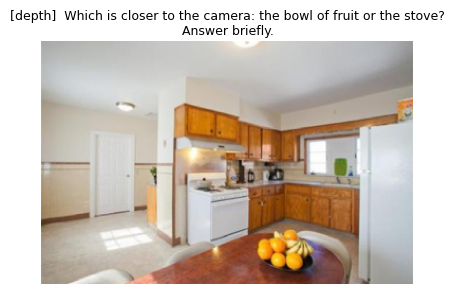

,answer,truth: “bowl”
orig_fp8,The bowl of fruit,✅
distilled_fp8,the bowl of fruit,✅
orig_nvfp4,the bowl of fruit,✅
distilled_nvfp4,bowl of fruit,✅


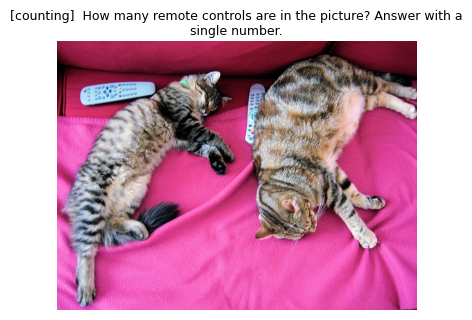

,answer,truth: “2”
orig_fp8,2,✅
distilled_fp8,2,✅
orig_nvfp4,2,✅
distilled_nvfp4,2,✅


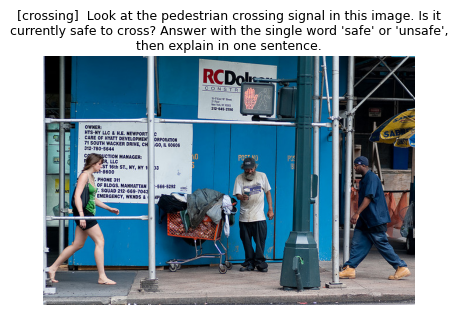

,answer,truth: “unsafe”
orig_fp8,"unsafe The pedestrian crossing signal displays a red hand symbol, indicating that it is unsafe to cross.",✅
distilled_fp8,"unsafe The pedestrian crossing signal is displaying a red hand, which means it is unsafe to cross.",✅
orig_nvfp4,"unsafe The pedestrian crossing signal displays a red hand icon, indicating that it is unsafe to cross.",✅
distilled_nvfp4,"unsafe The pedestrian crossing signal is displaying a red hand-no, which means it is unsafe to cross.",✅


In [ ]:
# Render the showdown saved by the §6 driver: image, question, all four answers.
import json, re
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from IPython.display import HTML, display

EVAL_ROOT = f"{BASE_PATH}/logs/edge-nvfp4-eval"
S = json.load(open(f"{EVAL_ROOT}/showdown.json"))
ORDER = ["orig_fp8", "distilled_fp8", "orig_nvfp4", "distilled_nvfp4"]

def mark(ans, truth):
    """Word-boundary match — an eyeballing aid, not a score."""
    return "✅" if any(re.search(rf"\b{re.escape(t)}\b", ans.lower())
                       for t in truth.lower().split("|")) else "❌"

for item in S["items"]:
    fig, ax = plt.subplots(figsize=(4.8, 3.5))
    ax.imshow(mpimg.imread(item["file"])); ax.axis("off")
    ax.set_title(f"[{item['id']}]  {item['q']}", fontsize=9, wrap=True)
    plt.show()
    rows = "".join(
        f"<tr><td style='padding:2px 14px;white-space:nowrap'><b>{v}</b></td>"
        f"<td style='padding:2px 14px;text-align:left'>{S['answers'].get(v, {}).get(item['id'], '<i>not run</i>')}</td>"
        f"<td style='text-align:center'>{mark(S['answers'].get(v, {}).get(item['id'], ''), item['truth'])}</td></tr>"
        for v in ORDER)
    display(HTML(
        "<table style='font-size:13px;border-collapse:collapse'>"
        "<tr><th></th><th style='text-align:left'>answer</th>"
        f"<th>truth: “{item['truth'].split('|')[0]}”</th></tr>" + rows + "</table>"))

In [21]:
# Aggregate lmms-eval result JSONs into the 4-way accuracy table.
import json, glob
EVAL_ROOT = f"{BASE_PATH}/logs/edge-nvfp4-eval"
ORDER = ["orig_fp8", "distilled_fp8", "orig_nvfp4", "distilled_nvfp4"]
TASKS = ["blink_relative_depth", "blink_counting", "blink_object_localization", "realworldqa"]
SHORT = {"blink_relative_depth": "B:depth", "blink_counting": "B:count",
         "blink_object_localization": "B:localiz", "realworldqa": "RWQA"}

def score(variant, task):
    files = sorted(glob.glob(f"{EVAL_ROOT}/{variant}/**/*results*.json", recursive=True))
    if not files: return None
    m = json.load(open(files[-1])).get("results", {}).get(task, {})
    for k, v in m.items():
        if isinstance(v, (int, float)) and not k.endswith("stderr") \
                and ("exact_match" in k or k.startswith(("blink_acc", "acc"))):
            return v * 100 if v <= 1 else v
    return None

print(f"{'variant':<17} | " + " | ".join(f"{SHORT[t]:>9}" for t in TASKS))
print("-" * 64)
for v in ORDER:
    row = " | ".join(f"{score(v, t):9.1f}" if isinstance(score(v, t), (int, float))
                      else f"{'...':>9}" for t in TASKS)
    print(f"{v:<17} | {row}")

variant           |   B:depth |   B:count | B:localiz |      RWQA
----------------------------------------------------------------
orig_fp8          |      68.0 |      55.0 |      54.0 |      64.0
distilled_fp8     |      53.0 |      64.0 |      45.0 |      52.0
orig_nvfp4        |      66.0 |      52.0 |      53.0 |      65.0
distilled_nvfp4   |      61.0 |      50.0 |      40.0 |      53.0


**Reading the table** (all numbers are accuracy %, 100-sample slices, ±5–7 % noise):

---
## 7. Robotics performance, the metrics that matter on edge

A robot is **not** a datacenter: it runs **fixed** models on **fixed** camera streams in a real-time perceive→reason→act loop. So aggregate throughput at high batch size is the wrong yardstick, what matters at **batch size 1** is *latency, responsiveness, and energy*. We measure three things with [aiperf](https://github.com/ai-dynamo/aiperf), all at concurrency 1:

| Metric | Robotics meaning |
|---|---|
| **Energy per decision** (J) | Battery life, how many inferences per Wh on an untethered robot. Read from on-board power telemetry: **INA3221 sysfs rails on Thor** (GPU + CPU/SoC + system board), **NVML on DGX Spark** (GPU-module power). |
| **Latency vs reasoning length** (OSL sweep) | Robots want *short* outputs, a reflex action or a brief justification, not a 500-token essay. How does loop latency grow as you spend more reasoning tokens? |
| **Responsiveness** (TTFT vs input context) | A streaming controller can act on the **first** token. How quickly does that arrive as sensor/history context grows? |

> ⚙️ **Warmup matters.** Each aiperf run warms up for ~8 s before measuring a ~25 s steady-state window (`--warmup-duration`/`--benchmark-duration`) so one-time Triton/CUDA JIT spikes don't pollute the numbers — warmup samples are discarded. At batch-1 every request is serial, so a fixed window is far faster than a large fixed request-count.

> 🖥️ **Shared GPU memory note.** On a Thor/Spark, free memory fluctuates and vLLM's startup memory-profiling can assert; the driver picks a memory-adaptive `--gpu-memory-utilization` to cope. On a *dedicated* device this is a non-issue. Runs use `--enforce-eager` for a tight memory footprint, CUDA-graph capture (the §5 compile path) would lower latency further across the board.

> 🔌 **Energy scope differs by platform.** Thor's INA3221 sums three rails → **total-board** Joules. Spark's NVML reports **GPU-module** Joules only (no full-board rail is exposed). Both are valid "energy per decision", just don't compare a Thor *board* number against a Spark *GPU* number directly. The chart labels which scope is in play.

**▶ Before the driver, run two cells: the §5.1 serving helpers, and the power-telemetry cell for your platform** (the two §7a cells just below — one for Thor, one for Spark). Then run the benchmark driver (~20–30 min — the progress bar ticks per benchmark stage and streams **live GPU wattage** while aiperf runs), then the plot cell.

### ⚠️ 7a. Power telemetry — **pick the cell for your platform**

The §7 benchmark driver below measures **energy per decision**, which needs a live power reading. Thor and DGX Spark expose power *completely differently*, so **run exactly ONE of the next two cells**, the one matching your hardware, before running the driver:

| Your platform | Run this cell | How it reads power |
|---|---|---|
| 🟠 **Thor AGX** (`sm_110`) | the **THOR AGX** cell | INA3221 rails via `/sys/class/hwmon` (total board) |
| 🟢 **DGX Spark / GB10** (`sm_121`) | the **DGX SPARK** cell | NVML `nvmlDeviceGetPowerUsage` (GPU module) |

Both define a `PowerSampler` with the same interface, so the driver and plot cells stay identical across platforms. If you skip this, the driver will stop with a clear reminder.

In [ ]:
# ║  PLATFORM = THOR AGX   ▶ RUN THIS CELL  (skip the DGX Spark cell below)     ║
# ╚═════════════════════════════════════════════════════════════════════════════╝
# Thor exposes per-rail power through the Tegra INA3221 on sysfs. We read the GPU
# rail and sum the three board rails directly: power_W = V(mV) * I(mA) / 1e6.
# The driver and plot cells pick this up via POWER_SCOPE automatically.
import time, threading
POWER_SCOPE = "total board (INA3221)"
HWMON = "/sys/class/hwmon/hwmon4"   # in1/curr1=VDD_GPU, in2=CPU_SOC, in3=VIN_SYS
def _rail_w(ch):
    v = int(open(f"{HWMON}/in{ch}_input").read())      # mV
    c = int(open(f"{HWMON}/curr{ch}_input").read())    # mA
    return (v / 1000.0) * (c / 1000.0)

class PowerSampler(threading.Thread):
    def __init__(self, hz=5): super().__init__(daemon=True); self.dt=1.0/hz; self.run_=True; self.gpu=[]; self.board=[]
    def run(self):
        while self.run_:
            try:
                self.gpu.append(_rail_w(1)); self.board.append(_rail_w(1)+_rail_w(2)+_rail_w(3))
            except Exception: pass
            time.sleep(self.dt)
    def stop(self): self.run_=False; time.sleep(0.3)
    def avg(self): return (sum(self.gpu)/len(self.gpu) if self.gpu else 0.0,
                           sum(self.board)/len(self.board) if self.board else 0.0)

print("Thor INA3221 power sampler ready —", POWER_SCOPE)
print("  sanity:", {f"rail{ch}_W": round(_rail_w(ch), 2) for ch in (1, 2, 3)})

In [22]:
# ║  PLATFORM = DGX SPARK (GB10)   ▶ RUN THIS CELL  (skip the Thor cell above)  ║
# ╚═════════════════════════════════════════════════════════════════════════════╝
# GB10 does NOT expose the Tegra INA3221 sysfs rails — /sys/class/hwmon has only
# acpitz / nvme / wifi. GPU-module power instead comes from NVML, which works
# from inside the container. NVML reports the GPU module only (not whole board),
# so "energy per decision" here is GPU energy — the directly comparable inference
# lever. The driver and plot cells pick this up via POWER_SCOPE automatically.
import time, threading
import pynvml as _nvml
_nvml.nvmlInit()
_NVML_H = _nvml.nvmlDeviceGetHandleByIndex(0)
POWER_SCOPE = "GPU module (NVML)"

def _gpu_w():
    return _nvml.nvmlDeviceGetPowerUsage(_NVML_H) / 1000.0   # mW -> W

class PowerSampler(threading.Thread):
    # Same (gpu, board) interface as the Thor sampler. Spark exposes only the GPU
    # rail, so board := gpu; the J calc downstream is therefore GPU-module energy.
    def __init__(self, hz=5): super().__init__(daemon=True); self.dt=1.0/hz; self.run_=True; self.gpu=[]; self.board=[]
    def run(self):
        while self.run_:
            try:
                w = _gpu_w(); self.gpu.append(w); self.board.append(w)
            except Exception: pass
            time.sleep(self.dt)
    def stop(self): self.run_=False; time.sleep(0.3)
    def avg(self): return (sum(self.gpu)/len(self.gpu) if self.gpu else 0.0,
                           sum(self.board)/len(self.board) if self.board else 0.0)

print("DGX Spark NVML power sampler ready —", POWER_SCOPE)
print(f"  sanity: GPU {_gpu_w():.2f} W")

DGX Spark NVML power sampler ready — GPU module (NVML)
  sanity: GPU 4.08 W


In [ ]:
# §7 — Batch-1 robotics benchmark suite: serves each variant (§5.1 helpers),
# samples power via the §7a platform PowerSampler, runs three aiperf workloads.
# Live progress: one tick per stage, with GPU wattage streaming in the postfix.
import json, os, subprocess, time
from tqdm.auto import tqdm

assert "serve" in globals(), "Run the §5.1 shared serving helpers cell first."
assert "PowerSampler" in globals() and "POWER_SCOPE" in globals(), (
    "Run the §7a power-telemetry cell for your platform first "
    "(the THOR AGX cell OR the DGX SPARK cell)."
)
print(f"power scope: {POWER_SCOPE}")

BENCH = f"{BASE_PATH}/benchmarks/edge-robotics"
os.makedirs(BENCH, exist_ok=True)
VARIANTS = {
    "orig_fp8":        f"{BASE_PATH}/Cosmos-Reason2-fp8",
    "distilled_fp8":   f"{BASE_PATH}/Cosmos-Reason2-distilled-fp8",
    "orig_nvfp4":      f"{BASE_PATH}/Cosmos-Reason2-nvfp4",
    "distilled_nvfp4": f"{BASE_PATH}/Cosmos-Reason2-distilled-nvfp4",
}
OSL_SWEEP = [8, 32, 64]        # short-output robotics regime (reflex -> brief reasoning)
ISL_SWEEP = [128, 512, 1024]   # sensor / history context (responsiveness)
ENERGY_OSL = 32                # representative single-decision output length

def aiperf(out, model, isl, osl, image, pbar, label, smp):
    os.makedirs(out, exist_ok=True)
    img = (["--image-batch-size", "1", "--image-width-mean", "768", "--image-height-mean", "768",
            "--image-width-stddev", "0", "--image-height-stddev", "0"] if image else [])
    cmd = ["aiperf", "profile", "--model", model, "--url", "http://localhost:8000",
           "--endpoint-type", "chat", "--streaming", "--concurrency", "1",
           "--warmup-duration", "8", "--benchmark-duration", "25", "--benchmark-grace-period", "12",
           *img, "--synthetic-input-tokens-mean", str(isl), "--synthetic-input-tokens-stddev", "0",
           "--output-tokens-mean", str(osl), "--output-tokens-stddev", "0",
           "--tokenizer", model, "--tokenizer-trust-remote-code", "--output-artifact-dir", out]
    proc = subprocess.Popen(cmd, stdout=open(f"{out}.log", "w"), stderr=subprocess.STDOUT)
    t0 = time.time()
    while proc.poll() is None:
        watts = f" │ {smp.gpu[-1]:.1f} W" if smp.gpu else ""
        pbar.set_postfix_str(f"{label} │ {int(time.time() - t0)}s{watts}")
        time.sleep(2)

STAGES = 1 + 1 + len(OSL_SWEEP) + len(ISL_SWEEP)   # startup + energy + sweeps
pbar = tqdm(total=len(VARIANTS) * STAGES, desc="robotics bench", unit="stage")
timing = {}
for name, ckpt in VARIANTS.items():
    t_var = time.time()
    p = serve(ckpt, f"{BENCH}/{name}_vllm.log", pick_util(),
              extra="--enforce-eager --max-num-seqs 8")
    try:
        if not wait_ready(pbar=pbar, label=name):
            print(f"!! vLLM did not come up for {name}; skipping"); continue
        t_up = time.time() - t_var
        pbar.update(1)
        # (1) energy: representative single decision, power sampled for the record
        smp = PowerSampler(); smp.start()
        aiperf(f"{BENCH}/{name}/loop", ckpt, 80, ENERGY_OSL, True,
               pbar, f"{name} │ energy OSL={ENERGY_OSL}", smp)
        smp.stop(); g, b = smp.avg()
        json.dump({"gpu_w": g, "board_w": b, "scope": POWER_SCOPE},
                  open(f"{BENCH}/{name}/power.json", "w"))
        pbar.update(1)
        # (2) reasoning-budget sweep  (3) responsiveness sweep — power shown live only
        for osl in OSL_SWEEP:
            disp = PowerSampler(); disp.start()
            aiperf(f"{BENCH}/{name}/osl_{osl}", ckpt, 80, osl, True,
                   pbar, f"{name} │ osl={osl}", disp)
            disp.stop(); pbar.update(1)
        for isl in ISL_SWEEP:
            disp = PowerSampler(); disp.start()
            aiperf(f"{BENCH}/{name}/isl_{isl}", ckpt, isl, 8, False,
                   pbar, f"{name} │ isl={isl}", disp)
            disp.stop(); pbar.update(1)
        timing[name] = {"startup_s": round(t_up), "total_s": round(time.time() - t_var),
                        "avg_gpu_w": round(g, 1)}
    finally:
        stop(p)
pbar.close()
print(f"{'variant':<18}{'startup':>9}{'total':>8}{'avg W':>8}")
for n, t in timing.items():
    print(f"{n:<18}{t['startup_s']:>8}s{t['total_s']:>7}s{t['avg_gpu_w']:>8}")
print("\nAll variants done. Artifacts under", BENCH)

power scope: GPU module (NVML)


robotics bench:   0%|          | 0/32 [00:00<?, ?stage/s]

Aggregate and plot the three robotics charts. The plotting helpers below read the aiperf artifacts and the sampled power, print the tables, and render the figures inline — re-run after your own benchmark to regenerate them.

ENERGY per decision (batch-1, OSL=32) — power scope: GPU module (NVML):
  variant           power W   GPU W  J/decision  decisions/Wh
  orig_fp8             26.5    26.5        15.1           238
  distilled_fp8        29.0    29.0        12.6           285
  orig_nvfp4           25.0    25.0        10.7           337
  distilled_nvfp4      25.6    25.6         8.9           406

OSL sweep — end-to-end latency (ms):
  variant              OSL=8    OSL=32    OSL=64
  orig_fp8               164       553       940
  distilled_fp8          143       452       709
  orig_nvfp4             137       427       776
  distilled_nvfp4        120       365       592

ISL sweep — time-to-first-token (ms):
  variant            ISL=128   ISL=512  ISL=1024
  orig_fp8                40        41        47
  distilled_fp8           36        39        40
  orig_nvfp4              32        35        41
  distilled_nvfp4         30        31        33


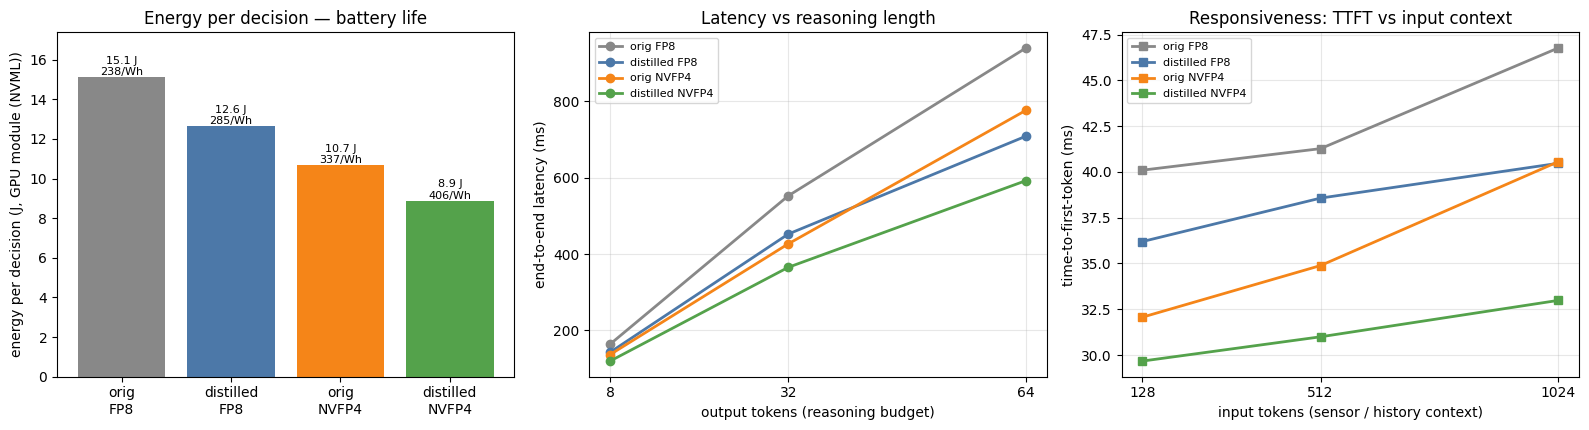

In [14]:
# §7 — Aggregate the robotics suite and plot the three charts that matter on edge.
import json, glob, os
import matplotlib.pyplot as plt

BENCH = f"{BASE_PATH}/benchmarks/edge-robotics"
ORDER = ["orig_fp8", "distilled_fp8", "orig_nvfp4", "distilled_nvfp4"]
LABEL = {"orig_fp8":"orig\nFP8","distilled_fp8":"distilled\nFP8","orig_nvfp4":"orig\nNVFP4","distilled_nvfp4":"distilled\nNVFP4"}
COLOR = {"orig_fp8":"#888888","distilled_fp8":"#4c78a8","orig_nvfp4":"#f58518","distilled_nvfp4":"#54a24b"}
OSL_SWEEP, ISL_SWEEP = [8, 32, 64], [128, 512, 1024]

def _sca(x): return x["avg"] if isinstance(x, dict) else x
def jload(p):
    fs = sorted(glob.glob(f"{p}/**/profile_export_aiperf.json", recursive=True))
    return json.load(open(fs[-1])) if fs else None

energy, osl, isl = {}, {}, {}
SCOPE = "board"   # overwritten from power.json below (Thor: total board / Spark: GPU module)
for v in ORDER:
    d = jload(f"{BENCH}/{v}/loop"); pj = f"{BENCH}/{v}/power.json"
    if d and os.path.exists(pj):
        pw = json.load(open(pj)); SCOPE = pw.get("scope", SCOPE)
        per_s = _sca(d["benchmark_duration"]) / _sca(d["request_count"])   # wall-time per decision
        energy[v] = {"board_w": pw["board_w"], "gpu_w": pw["gpu_w"],
                     "j": pw["board_w"] * per_s, "dec_per_wh": 3600.0 / (pw["board_w"] * per_s)}
    osl[v] = {o: jload(f"{BENCH}/{v}/osl_{o}")["request_latency"]["avg"]
              for o in OSL_SWEEP if jload(f"{BENCH}/{v}/osl_{o}")}
    isl[v] = {s: jload(f"{BENCH}/{v}/isl_{s}")["time_to_first_token"]["avg"]
              for s in ISL_SWEEP if jload(f"{BENCH}/{v}/isl_{s}")}

# ---- tables ----
print(f"ENERGY per decision (batch-1, OSL=32) — power scope: {SCOPE}:")
print(f"  {'variant':<16}{'power W':>9}{'GPU W':>8}{'J/decision':>12}{'decisions/Wh':>14}")
for v in ORDER:
    if v in energy:
        e = energy[v]; print(f"  {v:<16}{e['board_w']:>9.1f}{e['gpu_w']:>8.1f}{e['j']:>12.1f}{e['dec_per_wh']:>14.0f}")
print("\nOSL sweep — end-to-end latency (ms):")
print(f"  {'variant':<16}" + "".join(f"{'OSL='+str(o):>10}" for o in OSL_SWEEP))
for v in ORDER:
    print(f"  {v:<16}" + "".join(f"{osl[v].get(o, float('nan')):>10.0f}" for o in OSL_SWEEP))
print("\nISL sweep — time-to-first-token (ms):")
print(f"  {'variant':<16}" + "".join(f"{'ISL='+str(s):>10}" for s in ISL_SWEEP))
for v in ORDER:
    print(f"  {v:<16}" + "".join(f"{isl[v].get(s, float('nan')):>10.0f}" for s in ISL_SWEEP))

# ---- charts ----
present = [v for v in ORDER if osl.get(v)]
fig, ax = plt.subplots(1, 3, figsize=(16, 4.4))

# 1) energy per decision
pe = [v for v in ORDER if v in energy]
ax[0].bar([LABEL[v] for v in pe], [energy[v]["j"] for v in pe], color=[COLOR[v] for v in pe])
ax[0].set_ylabel(f"energy per decision (J, {SCOPE})"); ax[0].set_title("Energy per decision — battery life")
for i, v in enumerate(pe):
    ax[0].text(i, energy[v]["j"], f"{energy[v]['j']:.1f} J\n{energy[v]['dec_per_wh']:.0f}/Wh", ha="center", va="bottom", fontsize=8)
ax[0].margins(y=0.15)

# 2) reasoning-budget sweep
for v in present:
    xs = [o for o in OSL_SWEEP if o in osl[v]]
    ax[1].plot(xs, [osl[v][o] for o in xs], marker="o", lw=2, label=LABEL[v].replace("\n", " "), color=COLOR[v])
ax[1].set_xlabel("output tokens (reasoning budget)"); ax[1].set_ylabel("end-to-end latency (ms)")
ax[1].set_title("Latency vs reasoning length"); ax[1].set_xticks(OSL_SWEEP); ax[1].grid(alpha=0.3); ax[1].legend(fontsize=8)

# 3) responsiveness — TTFT vs input context
for v in present:
    xs = [s for s in ISL_SWEEP if s in isl[v]]
    ax[2].plot(xs, [isl[v][s] for s in xs], marker="s", lw=2, label=LABEL[v].replace("\n", " "), color=COLOR[v])
ax[2].set_xlabel("input tokens (sensor / history context)"); ax[2].set_ylabel("time-to-first-token (ms)")
ax[2].set_title("Responsiveness: TTFT vs input context"); ax[2].set_xticks(ISL_SWEEP); ax[2].grid(alpha=0.3); ax[2].legend(fontsize=8)

plt.tight_layout(); plt.show()


**What the three charts tell:**

- **Energy per decision**: The energy efficiency of the model.
- **Latency vs reasoning length**: How much reasoning can be afforded inside the same loop-time budget.
- **Responsiveness (TTFT)**: Depending on the implementation a streaming robotics controller could start acting as soon as the first token lands.

---
## 8. Wrap-up

We took the pretrained, pruned + distilled Cosmos-Reason 2 and made it an **edge-ready artifact on Thor AGX or DGX Spark**:

1. **Quantized to NVFP4**
2. **Compiled + served**
3. **Evaluated quality**
4. **Evaluated edge metrics**

### Taking it further: TensorRT-LLM engine build

vLLM compiled and served the NVFP4 checkpoint with no extra steps, which is why we used it. For the most effective edge latency, build a **TensorRT-LLM engine** from the *same* ModelOpt NVFP4 checkpoint, TRT-LLM consumes the unified HF quant format directly:

```bash
# (TRT-LLM is built from source on Thor/Tegra — no prebuilt aarch64 wheel yet.)
trtllm-build --checkpoint_dir $BASE_PATH/Cosmos-Reason2-distilled-nvfp4 \
             --output_dir      $BASE_PATH/engines/distilled-nvfp4 \
             --gemm_plugin auto --max_batch_size 8
trtllm-serve $BASE_PATH/engines/distilled-nvfp4 --host 0.0.0.0 --port 8000
```